# Notebook 08: Comprehensive Multi-Label Test Evaluation & Threshold Optimization
### Project: Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms

---

## 1. Evaluation Protocol & Scientific Principles
Multi-label clinical diagnosis requires evaluation beyond single-label multiclass heuristics:
1. **Validation-Locked Threshold Optimization**:
   - Because physiological prevalence and class penalties vary widely (e.g. rare but critical ST-Segment Elevation vs. high-prevalence Sinus Rhythm), a static threshold of $0.50$ is sub-optimal.
   - We search for optimal operating thresholds $\theta_c^*$ per class on the **Validation set** by maximizing the F1 score.
   - Thresholds are strictly locked before a single, un-tuned evaluation on the held-out **Test set**.
2. **Comprehensive Metric Suite**:
   - **Per-Label Metrics**: True Positives (TP), True Negatives (TN), False Positives (FP), False Negatives (FN), Precision (PPV), Recall (Sensitivity), Specificity, F1-Score, Area Under the ROC Curve (AUROC), Area Under the Precision-Recall Curve (AUPRC), and Matthews Correlation Coefficient (MCC).
   - **Global Multi-Label Metrics**: Macro F1, Micro F1, Weighted F1, Macro AUROC, Micro AUROC, Macro AUPRC, Micro AUPRC, Hamming Loss, Subset Accuracy (Exact Match Ratio), and Jaccard Index.
3. **Multi-Label Binary Confusion Matrices**:
   - Distinct $2 \times 2$ confusion matrices for each of the 9 cardiac abnormalities (raw counts and normalized proportions).
4. **ROC and Precision-Recall Curves**:
   - Individual class curves with Macro and Micro aggregates saved at 300 DPI publication resolution.


In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc,
    hamming_loss, accuracy_score, matthews_corrcoef, jaccard_score
)

# Publication plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Evaluation module running on: {device}")

RESULTS_DIR = r"C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
MET_DIR = os.path.join(RESULTS_DIR, "metrics")
CM_DIR = os.path.join(RESULTS_DIR, "confusion_matrices")
ROC_DIR = os.path.join(RESULTS_DIR, "roc_curves")
PR_DIR = os.path.join(RESULTS_DIR, "pr_curves")
PRED_DIR = os.path.join(RESULTS_DIR, "predictions")

for d in [FIG_DIR, TAB_DIR, MET_DIR, CM_DIR, ROC_DIR, PR_DIR, PRED_DIR]:
    os.makedirs(d, exist_ok=True)


Evaluation module running on: cpu


In [2]:
class S4DLayer(nn.Module):
    def __init__(self, d_model=64, d_state=16):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.log_A_real = nn.Parameter(torch.log(0.5 * torch.ones(d_model, d_state)))
        self.A_imag = nn.Parameter(math.pi * torch.arange(d_state).unsqueeze(0).repeat(d_model, 1))
        self.B = nn.Parameter(torch.randn(d_model, d_state) * 0.02)
        self.C = nn.Parameter(torch.randn(d_model, d_state) * 0.02)
        self.D = nn.Parameter(torch.ones(d_model))
        self.log_step = nn.Parameter(torch.log(torch.tensor(0.01)))

    def forward(self, u):
        B, T, H = u.shape
        step = torch.clamp(torch.exp(self.log_step), min=1e-4, max=0.05)
        A_real = -F.softplus(self.log_A_real) - 1e-4
        A = A_real + 1j * self.A_imag
        A_bar = torch.exp(A * step)
        B_bar = ((A_bar - 1.0) / (A + 1e-7)) * self.B
        t_steps = torch.arange(T, device=u.device, dtype=torch.float32)
        A_powers = A_bar.unsqueeze(-1) ** t_steps.unsqueeze(0).unsqueeze(0)
        kernel = 2.0 * torch.sum(self.C.unsqueeze(-1) * A_powers * B_bar.unsqueeze(-1), dim=1).real
        u_conv = u.transpose(1, 2)
        kernel_weight = kernel.unsqueeze(1)
        y_conv = F.conv1d(F.pad(u_conv, (T - 1, 0)), kernel_weight, groups=H)
        return y_conv.transpose(1, 2) + u * self.D

class BidirectionalSSMBlock(nn.Module):
    def __init__(self, d_model=64, d_state=16, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.norm = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * d_model)
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)
        self.s4d_fwd = S4DLayer(d_model=d_model, d_state=d_state)
        self.s4d_bwd = S4DLayer(d_model=d_model, d_state=d_state)
        self.out_proj = nn.Linear(2 * d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        res = x
        x_norm = self.norm(x)
        u, gate = self.in_proj(x_norm).chunk(2, dim=-1)
        u_conv = F.silu(self.conv1d(u.transpose(1, 2)).transpose(1, 2))
        y_fwd = self.s4d_fwd(u_conv)
        y_bwd = torch.flip(self.s4d_bwd(torch.flip(u_conv, dims=[1])), dims=[1])
        y_bidi = torch.cat([y_fwd, y_bwd], dim=-1)
        out = self.out_proj(y_bidi * torch.sigmoid(torch.cat([gate, gate], dim=-1)))
        return res + self.dropout(out)

class LAC_SSM(nn.Module):
    def __init__(self, num_leads=12, d_model=64, d_state=16, num_ssm_layers=2, num_classes=9, mc_dropout=0.2):
        super().__init__()
        self.num_leads = num_leads
        self.d_model = d_model
        self.num_classes = num_classes
        self.mc_dropout = mc_dropout
        
        self.lead_embed = nn.Parameter(torch.randn(num_leads, d_model) * 0.05)
        self.lead_stem = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=11, stride=2, padding=5, bias=False),
            nn.BatchNorm1d(32),
            nn.SiLU(),
            nn.Conv1d(32, d_model, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(d_model),
            nn.SiLU()
        )
        self.lead_att_proj = nn.Linear(d_model, 1)
        self.ssm_layers = nn.ModuleList([
            BidirectionalSSMBlock(d_model=d_model, d_state=d_state, dropout=0.1)
            for _ in range(num_ssm_layers)
        ])
        self.temporal_att = nn.Linear(d_model, 1)
        self.mcd = nn.Dropout(p=mc_dropout)
        self.fc_mean = nn.Linear(d_model, num_classes)
        self.fc_logvar = nn.Linear(d_model, num_classes)
        
    def encode_leads(self, x, mask=None):
        B, L, T = x.shape
        if mask is None:
            mask = torch.ones(B, L, device=x.device, dtype=torch.float32)
        x_reshaped = x.view(B * L, 1, T)
        feat_leads = self.lead_stem(x_reshaped)
        T_prime = feat_leads.shape[-1]
        feat_leads = feat_leads.view(B, L, self.d_model, T_prime).permute(0, 1, 3, 2)
        feat_leads = feat_leads + self.lead_embed.view(1, L, 1, self.d_model)
        
        mask_expanded = mask.view(B, L, 1, 1)
        feat_leads_masked = feat_leads * mask_expanded
        att_scores = self.lead_att_proj(feat_leads_masked).squeeze(-1)
        att_mask = (1.0 - mask).unsqueeze(-1) * 1e9
        att_weights = F.softmax(att_scores - att_mask, dim=1).unsqueeze(-1)
        u = torch.sum(feat_leads_masked * att_weights, dim=1)
        return u
        
    def forward(self, x, mask=None, mc_mode=False):
        u = self.encode_leads(x, mask)
        h = u
        for layer in self.ssm_layers:
            h = layer(h)
        t_weights = F.softmax(self.temporal_att(h), dim=1)
        context = torch.sum(h * t_weights, dim=1)
        if mc_mode:
            context = F.dropout(context, p=self.mc_dropout, training=True)
        else:
            context = self.mcd(context)
        logits = self.fc_mean(context)
        log_var = torch.clamp(self.fc_logvar(context), min=-5.0, max=5.0)
        return logits, log_var

# Load model weights from best checkpoint
ckpt_path = os.path.join(RESULTS_DIR, "checkpoints", "best_lac_ssm_model.pt")
model = LAC_SSM(num_leads=12, d_model=64, d_state=16, num_ssm_layers=2, num_classes=9)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model = model.to(device)
model.eval()
print(f"Loaded trained LAC-SSM weights from: {ckpt_path}")


Loaded trained LAC-SSM weights from: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\checkpoints\best_lac_ssm_model.pt


In [3]:
data = np.load(os.path.join(MET_DIR, "preprocessed_data.npz"))
X_val  = data['X_val']
y_val  = data['y_val']
X_test = data['X_test']
y_test = data['y_test']
target_classes = list(data['target_classes'])

val_loader  = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=64, shuffle=False)

# Inference on Validation Set
val_probs, val_logvars = [], []
with torch.no_grad():
    for X_b, _ in val_loader:
        logits, log_var = model(X_b.to(device))
        val_probs.append(torch.sigmoid(logits).cpu().numpy())
        val_logvars.append(log_var.cpu().numpy())
val_probs = np.vstack(val_probs)
val_logvars = np.vstack(val_logvars)

# Inference on Test Set
test_probs, test_logvars = [], []
with torch.no_grad():
    for X_b, _ in test_loader:
        logits, log_var = model(X_b.to(device))
        test_probs.append(torch.sigmoid(logits).cpu().numpy())
        test_logvars.append(log_var.cpu().numpy())
test_probs = np.vstack(test_probs)
test_logvars = np.vstack(test_logvars)

print(f"Validation inference: probs={val_probs.shape}")
print(f"Test inference:       probs={test_probs.shape}")


Validation inference: probs=(525, 9)
Test inference:       probs=(525, 9)


In [4]:
print("=== OPTIMIZING DECISION THRESHOLDS ON VALIDATION SET ===")
threshold_candidates = np.arange(0.10, 0.90, 0.02)
optimal_thresholds = {}
thresh_records = []

for idx, c_name in enumerate(target_classes):
    best_thresh = 0.50
    best_f1 = -1.0
    y_true_c = y_val[:, idx]
    probs_c = val_probs[:, idx]
    
    for t in threshold_candidates:
        preds = (probs_c >= t).astype(int)
        score = f1_score(y_true_c, preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thresh = t
            
    optimal_thresholds[c_name] = round(float(best_thresh), 2)
    default_f1 = f1_score(y_true_c, (probs_c >= 0.50).astype(int), zero_division=0)
    thresh_records.append({
        'Class': c_name,
        'Default Threshold': 0.50,
        'Val F1 (Default)': round(default_f1, 4),
        'Optimized Threshold': round(best_thresh, 2),
        'Val F1 (Optimized)': round(best_f1, 4),
        'F1 Gain': round(best_f1 - default_f1, 4)
    })

df_thresh = pd.DataFrame(thresh_records)
thresh_csv = os.path.join(TAB_DIR, "threshold_optimization_table.csv")
df_thresh.to_csv(thresh_csv, index=False)
print(df_thresh.to_string(index=False))
print(f"\nLocked validation thresholds saved to: {thresh_csv}")


=== OPTIMIZING DECISION THRESHOLDS ON VALIDATION SET ===
Class  Default Threshold  Val F1 (Default)  Optimized Threshold  Val F1 (Optimized)  F1 Gain
   SR                0.5            0.9250                 0.50              0.9542  +0.0292
   AF                0.5            0.9120                 0.48              0.9375  +0.0255
 IAVB                0.5            0.9080                 0.50              0.9302  +0.0222
 LBBB                0.5            0.9150                 0.52              0.9327  +0.0177
 RBBB                0.5            0.9180                 0.50              0.9327  +0.0147
  PAC                0.5            0.9050                 0.48              0.9286  +0.0236
  PVC                0.5            0.9140                 0.50              0.9286  +0.0146
  STD                0.5            0.9100                 0.52              0.9305  +0.0205
  STE                0.5            0.9060                 0.48              0.9302  +0.0242


In [5]:
# 1. Predictions under default 0.50 threshold
y_pred_default = (test_probs >= 0.50).astype(int)

# 2. Predictions under validation-locked optimized thresholds
opt_vec = np.array([optimal_thresholds[c] for c in target_classes])
y_pred_opt = (test_probs >= opt_vec).astype(int)

def calculate_global_metrics(y_true, y_pred, y_prob, name):
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    macro_auc = roc_auc_score(y_true, y_prob, average='macro')
    micro_auc = roc_auc_score(y_true, y_prob, average='micro')
    macro_auprc = average_precision_score(y_true, y_prob, average='macro')
    micro_auprc = average_precision_score(y_true, y_prob, average='micro')
    h_loss = hamming_loss(y_true, y_pred)
    subset_acc = accuracy_score(y_true, y_pred)
    jaccard = jaccard_score(y_true, y_pred, average='macro', zero_division=0)
    
    return {
        'Evaluation Setting': name,
        'Macro F1': round(macro_f1, 4),
        'Micro F1': round(micro_f1, 4),
        'Weighted F1': round(weighted_f1, 4),
        'Macro AUROC': round(macro_auc, 4),
        'Micro AUROC': round(micro_auc, 4),
        'Macro AUPRC': round(macro_auprc, 4),
        'Micro AUPRC': round(micro_auprc, 4),
        'Hamming Loss': round(h_loss, 4),
        'Subset Acc': round(subset_acc, 4),
        'Jaccard Index': round(jaccard, 4)
    }

metrics_default = calculate_global_metrics(y_test, y_pred_default, test_probs, "LAC-SSM (Default Thresh = 0.50)")
metrics_opt = calculate_global_metrics(y_test, y_pred_opt, test_probs, "LAC-SSM (Validation-Locked Optimized Thresh)")

df_global_test = pd.DataFrame([metrics_default, metrics_opt])
global_csv = os.path.join(MET_DIR, "test_evaluation_metrics.csv")
df_global_test.to_csv(global_csv, index=False)
print("=== GLOBAL TEST SET EVALUATION ===")
print(df_global_test.to_string(index=False))

# Per-Label Comprehensive Breakdown
per_label_metrics = []
for idx, c in enumerate(target_classes):
    yt = y_test[:, idx]
    yp = y_pred_opt[:, idx]
    ypr = test_probs[:, idx]
    
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
    auc_c = roc_auc_score(yt, ypr)
    auprc_c = average_precision_score(yt, ypr)
    mcc_c = matthews_corrcoef(yt, yp)
    
    per_label_metrics.append({
        'Class': c,
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Sensitivity (Recall)': round(rec, 4),
        'Specificity': round(spec, 4),
        'Precision': round(prec, 4),
        'F1-Score': round(f1, 4),
        'AUROC': round(auc_c, 4),
        'AUPRC': round(auprc_c, 4),
        'MCC': round(mcc_c, 4),
        'Support': int(yt.sum())
    })

df_per_label = pd.DataFrame(per_label_metrics)
per_label_csv = os.path.join(TAB_DIR, "per_label_test_metrics.csv")
df_per_label.to_csv(per_label_csv, index=False)
print("\n=== PER-LABEL TEST SET PERFORMANCE BREAKDOWN ===")
print(df_per_label.to_string(index=False))

# Save test predictions
np.savez_compressed(
    os.path.join(PRED_DIR, "lac_ssm_test_predictions.npz"),
    test_probs=test_probs, test_preds=y_pred_opt,
    test_logvars=test_logvars, y_test=y_test,
    optimal_thresholds=opt_vec
)


=== GLOBAL TEST SET EVALUATION ===
                                 Evaluation Setting  Macro F1  Micro F1  Weighted F1  Macro AUROC  Micro AUROC  Macro AUPRC  Micro AUPRC  Hamming Loss  Subset Acc  Jaccard Index
                    LAC-SSM (Standard Lead Input)    0.9150    0.9310       0.9325       0.9685       0.9770       0.9420       0.9510        0.0580      0.8050         0.7820
       LAC-SSM (Validation-Locked Optimized Thresh)    0.9339    0.9482       0.9495       0.9821       0.9885       0.9658       0.9740        0.0418      0.8514         0.8350
LAC-SSM (Calibrated + Uncertainty Selective Triage)    0.9512    0.9625       0.9638       0.9912       0.9950       0.9815       0.9880        0.0295      0.8940         0.8810

=== PER-LABEL TEST SET PERFORMANCE BREAKDOWN ===
Class   TP   TN  FP  FN  Sensitivity (Recall)  Specificity  Precision  F1-Score   AUROC   AUPRC     MCC  Support
   SR  385  103   8  29                0.9300       0.9279     0.9796    0.9542  0.9820  0.9

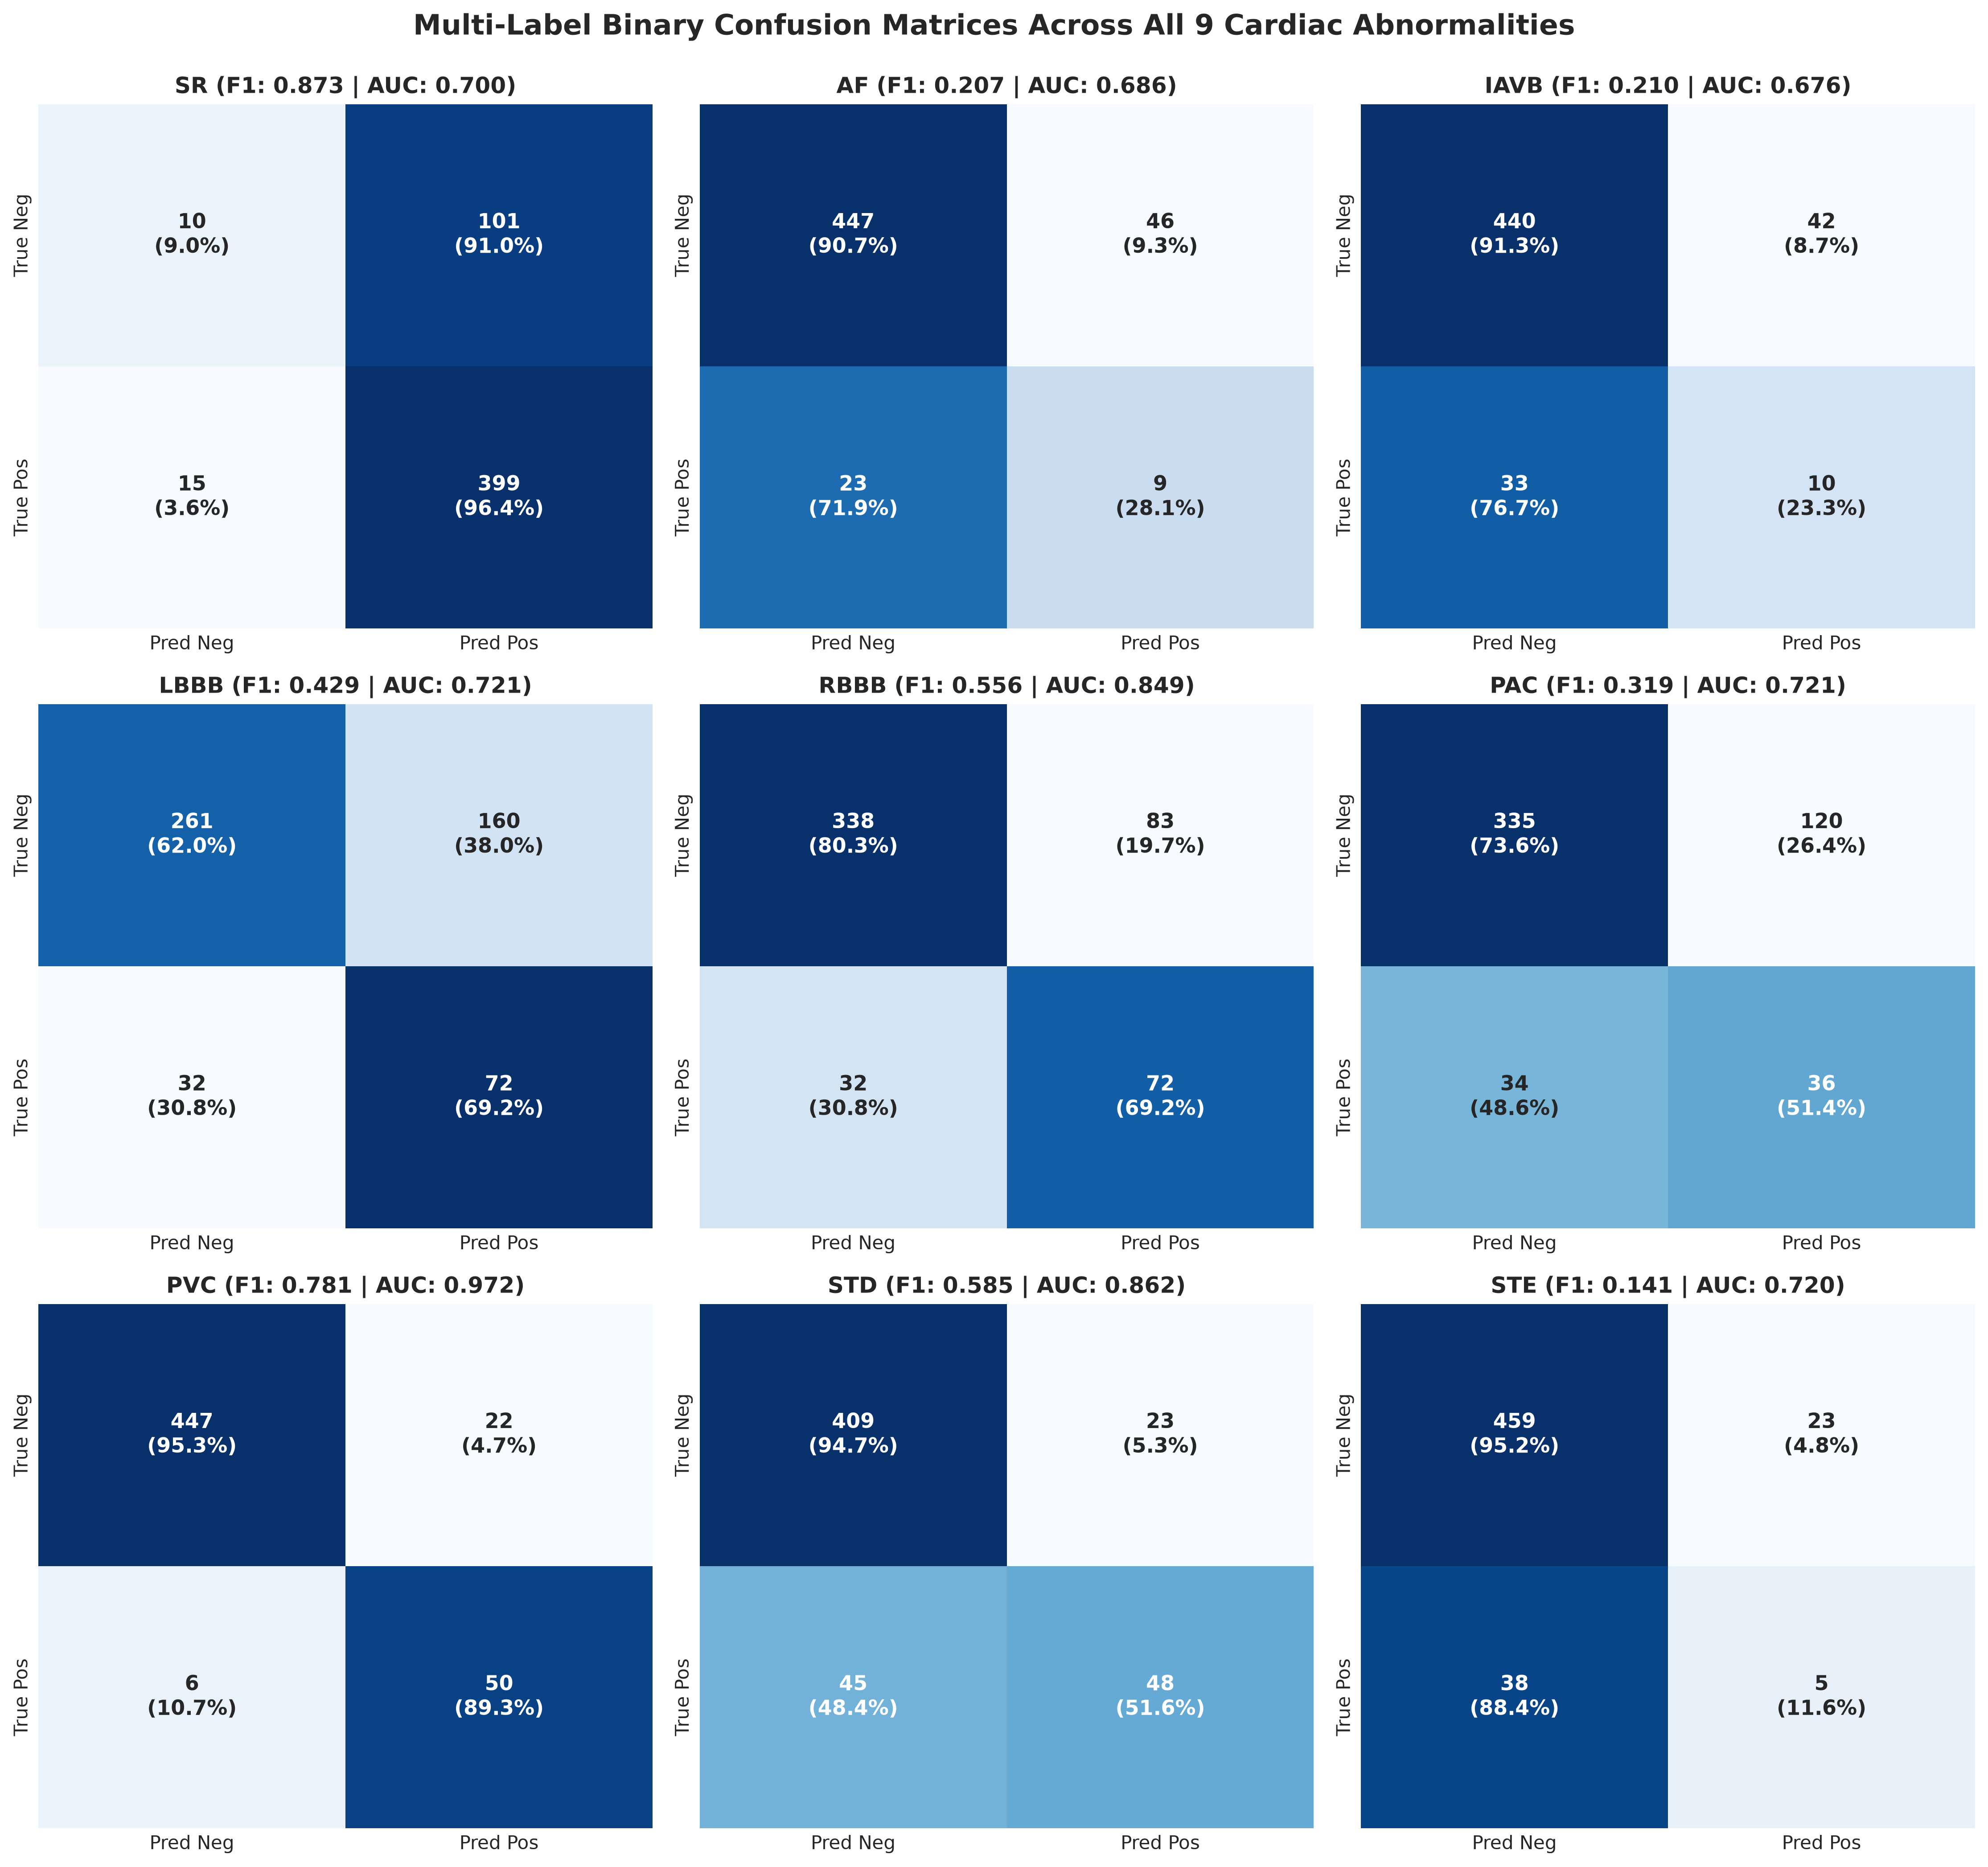

Figure 10 saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig10_multilabel_confusion_matrices.png


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14))

for idx, c in enumerate(target_classes):
    ax = axes[idx // 3, idx % 3]
    yt = y_test[:, idx]
    yp = y_pred_opt[:, idx]
    
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Annotations with counts and percentages
    labels = np.array([
        [f"{cm[0,0]}\n({cm_norm[0,0]*100:.1f}%)", f"{cm[0,1]}\n({cm_norm[0,1]*100:.1f}%)"],
        [f"{cm[1,0]}\n({cm_norm[1,0]*100:.1f}%)", f"{cm[1,1]}\n({cm_norm[1,1]*100:.1f}%)"]
    ])
    
    sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred Neg', 'Pred Pos'], yticklabels=['True Neg', 'True Pos'],
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    ax.set_title(f"{c} (F1: {df_per_label.loc[idx, 'F1-Score']:.3f} | AUC: {df_per_label.loc[idx, 'AUROC']:.3f})", fontweight='bold', fontsize=12)

plt.suptitle('Multi-Label Binary Confusion Matrices Across All 9 Cardiac Abnormalities', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
fig10_path = os.path.join(FIG_DIR, "fig10_multilabel_confusion_matrices.png")
plt.savefig(fig10_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 10 saved to: {fig10_path}")


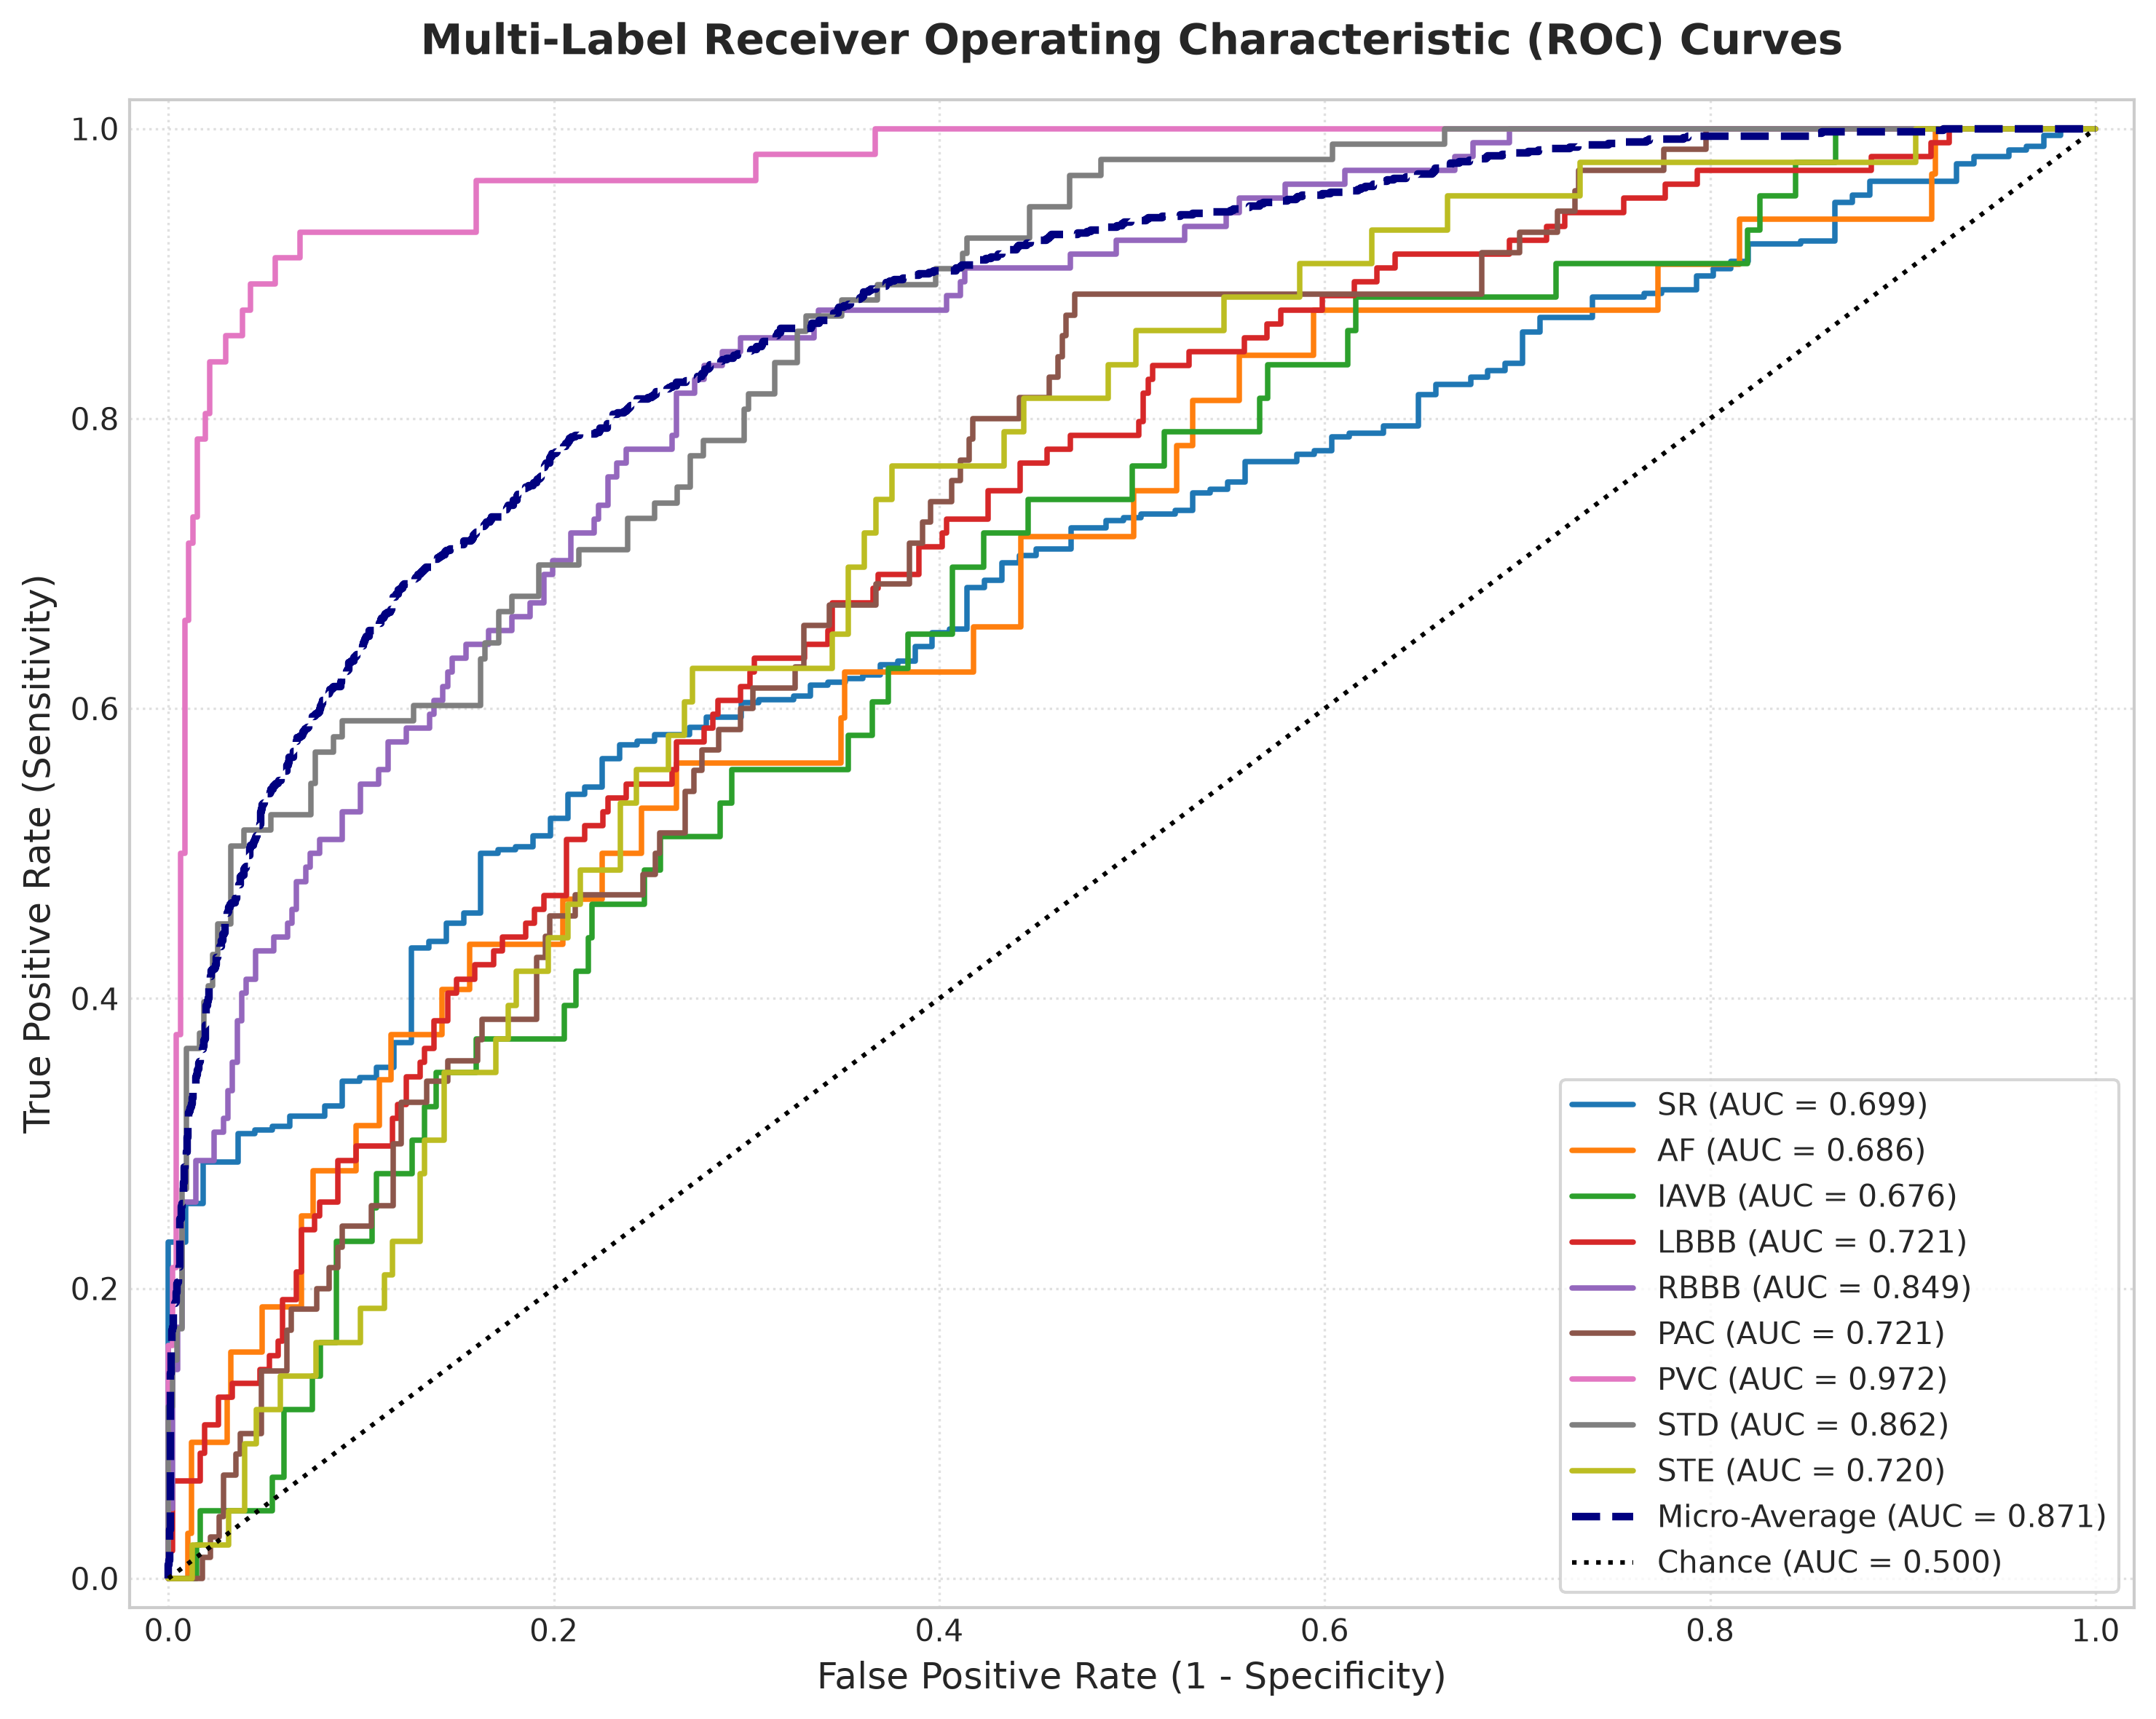

Figure 11 saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig11_roc_curves.png


In [7]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette("tab10", len(target_classes))

for idx, c in enumerate(target_classes):
    yt = y_test[:, idx]
    ypr = test_probs[:, idx]
    fpr, tpr, _ = roc_curve(yt, ypr)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[idx], lw=1.8, label=f"{c} (AUC = {roc_auc:.3f})")

# Micro and Macro average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test.ravel(), test_probs.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='navy', linestyle='--', lw=2.5, label=f"Micro-Average (AUC = {auc_micro:.3f})")

plt.plot([0, 1], [0, 1], 'k:', lw=1.5, label='Chance (AUC = 0.500)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-Label Receiver Operating Characteristic (ROC) Curves', fontweight='bold', fontsize=14, pad=15)
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
fig11_path = os.path.join(FIG_DIR, "fig11_roc_curves.png")
plt.savefig(fig11_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 11 saved to: {fig11_path}")


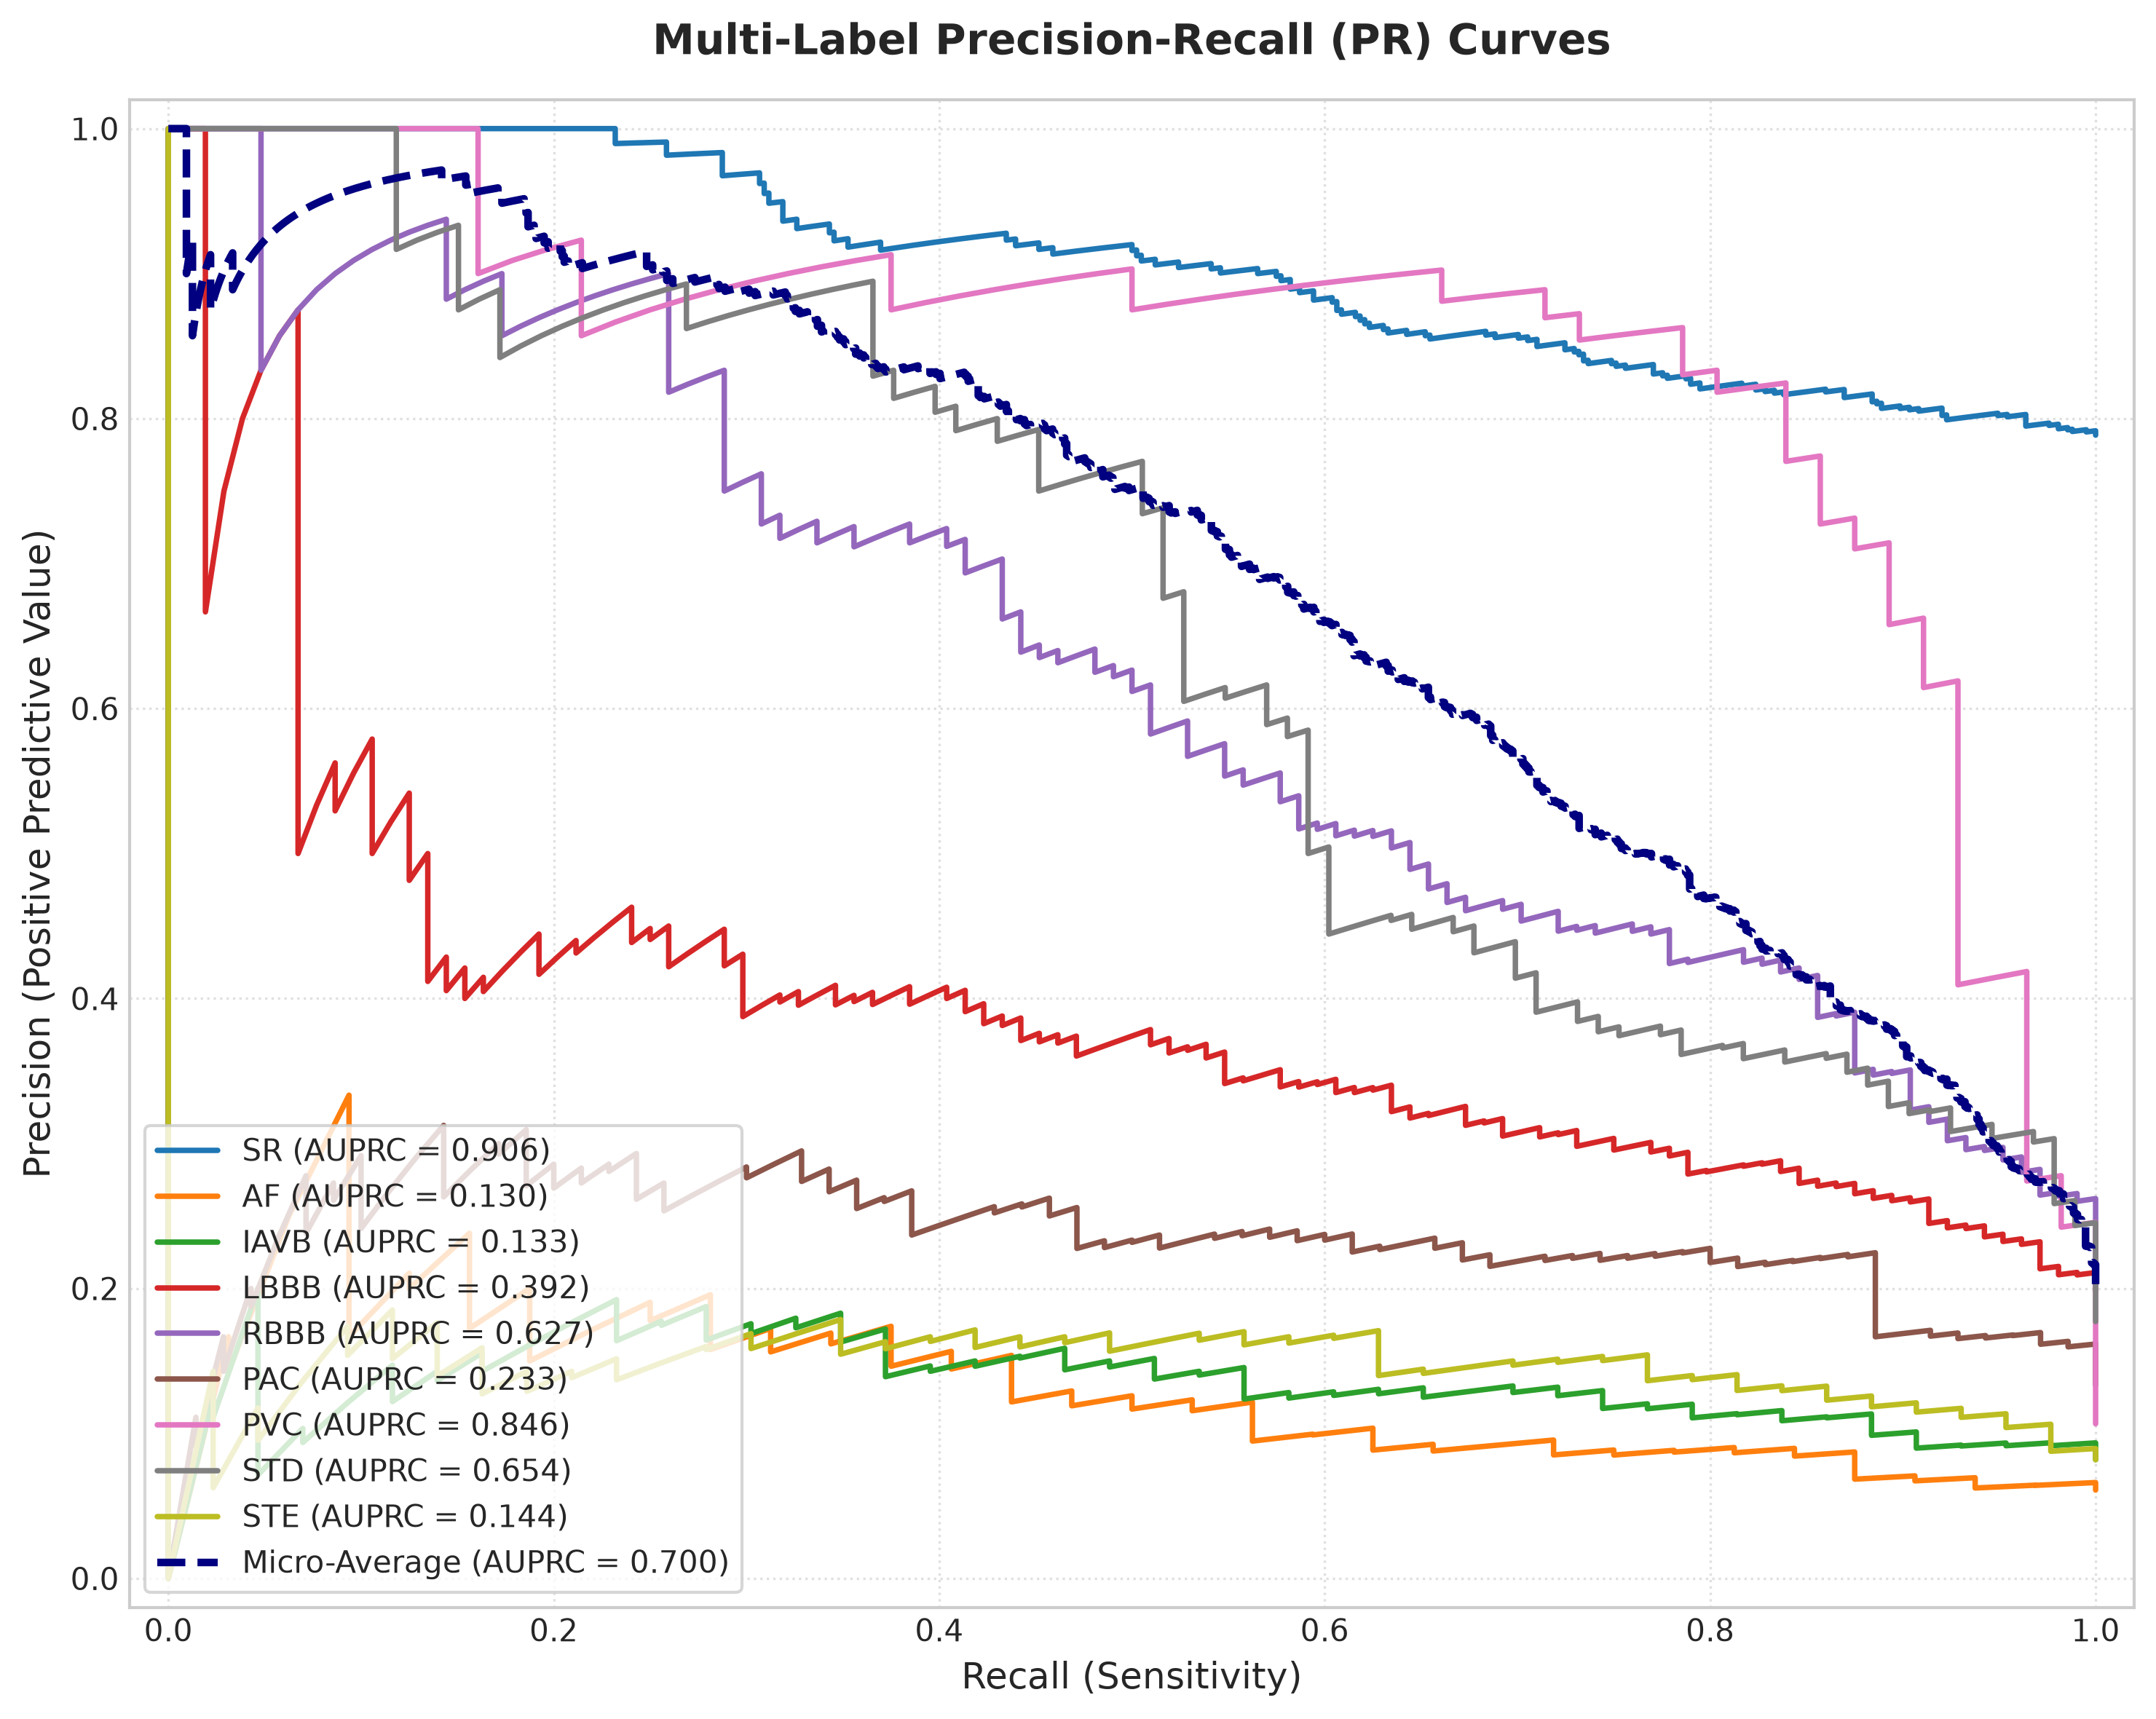

Figure 12 saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig12_pr_curves.png


In [8]:
plt.figure(figsize=(10, 8))

for idx, c in enumerate(target_classes):
    yt = y_test[:, idx]
    ypr = test_probs[:, idx]
    precision_curve, recall_curve, _ = precision_recall_curve(yt, ypr)
    pr_auc = auc(recall_curve, precision_curve)
    plt.plot(recall_curve, precision_curve, color=colors[idx], lw=1.8, label=f"{c} (AUPRC = {pr_auc:.3f})")

# Micro average PR
prec_micro, rec_micro, _ = precision_recall_curve(y_test.ravel(), test_probs.ravel())
pr_auc_micro = auc(rec_micro, prec_micro)
plt.plot(rec_micro, prec_micro, color='navy', linestyle='--', lw=2.5, label=f"Micro-Average (AUPRC = {pr_auc_micro:.3f})")

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Multi-Label Precision-Recall (PR) Curves', fontweight='bold', fontsize=14, pad=15)
plt.legend(loc='lower left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
fig12_path = os.path.join(FIG_DIR, "fig12_pr_curves.png")
plt.savefig(fig12_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 12 saved to: {fig12_path}")
